# Part 9: Discrete-Time Smoothing

In the filtering notebooks, we used `Filter` to compute a marginal likelihood and, optionally, filtering summaries of the form

$$
p(x_t \mid y_{1:t}).
$$

Filtering is causal: the state estimate at time $t$ only uses observations up to time $t$. Smoothing answers a different question:

$$
p(x_t \mid y_{1:T}).
$$

That is, after seeing the whole data window, what do we believe about every latent state inside that window? This is often the quantity we want for retrospective analysis: reconstructing trajectories, denoising latent states, checking model fit, and initializing forecasts from the best available terminal state.

In this notebook we will use the following two-dimensional local-trend model. The latent state is $x_k = (p_k, v_k)$, where $p_k$ is position and $v_k$ is velocity:

$$
\begin{aligned}
\alpha &\sim \operatorname{Uniform}(0.5, 0.99), \\
x_0 &\sim \mathcal{N}\!\left(
\begin{bmatrix}0 \\ 0.15\end{bmatrix},
\begin{bmatrix}0.2^2 & 0 \\ 0 & 0.1^2\end{bmatrix}
\right), \\
x_{k+1} \mid x_k, \alpha &\sim \mathcal{N}\!\left(
\begin{bmatrix}1 & 1 \\ 0 & \alpha\end{bmatrix} x_k,
\begin{bmatrix}0.05^2 & 0 \\ 0 & 0.03^2\end{bmatrix}
\right), \\
y_k \mid x_k &\sim \mathcal{N}\!\left(\begin{bmatrix}1 & 0\end{bmatrix} x_k,\ 0.1^2\right).
\end{aligned}
$$

Only position is observed. Velocity is inferred from the dynamical structure and the whole observation sequence.

## What this tutorial covers

We will build a small discrete-time local-trend model, generate synthetic data, run a Kalman smoother, use the smoother marginal likelihood inside NUTS, and then forecast forward from the final smoothed state.

The forecast step is intentionally constrained: in the current release, `Smoother` only supports `predict_times >= max(obs_times)`. Prediction inside the smoothing window is not implemented yet, because inserting extra times into a discrete-time model would change the transition sequence itself.

### Imports

In [1]:
import arviz as az
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, Filter, Smoother
from dynestyx.inference.configs.filter import KFConfig
from dynestyx.inference.configs.smoother import KFSmootherConfig

## Defining the Model

The code below is a direct translation of the equations above into an `LTI_discrete` model. The unknown parameter `alpha` controls how persistent the velocity component is.

In [2]:
def local_trend_model(obs_times=None, obs_values=None, predict_times=None):
    alpha = numpyro.sample("alpha", dist.Uniform(0.5, 0.99))

    dynamics = dsx.LTI_discrete(
        A=jnp.array([[1.0, 1.0], [0.0, alpha]]),
        Q=jnp.diag(jnp.array([0.05**2, 0.03**2])),
        H=jnp.array([[1.0, 0.0]]),
        R=jnp.array([[0.25**2]]),
        initial_mean=jnp.array([0.0, 0.15]),
        initial_cov=jnp.diag(jnp.array([0.2**2, 0.1**2])),
    )

    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

### Generate synthetic data

As in earlier tutorials, we use a simulator handler to generate data from the exact same model function. The model does not know whether it is being simulated, filtered, or smoothed; the active handler decides how to interpret `dsx.sample`.

In [3]:
alpha_true = jnp.array(0.88)
obs_times = jnp.arange(0.0, 200.0, 1.0)

data_predictive = Predictive(
    local_trend_model,
    params={"alpha": alpha_true},
    num_samples=1,
    exclude_deterministic=False,
)

with DiscreteTimeSimulator(n_simulations=1):
    synthetic = data_predictive(jr.PRNGKey(0), predict_times=obs_times)

true_states = synthetic["f_states"][0, 0]
obs_values = synthetic["f_observations"][0, 0]
plot_times = synthetic["f_times"][0, 0]

true_states.shape, obs_values.shape

((200, 2), (200, 1))

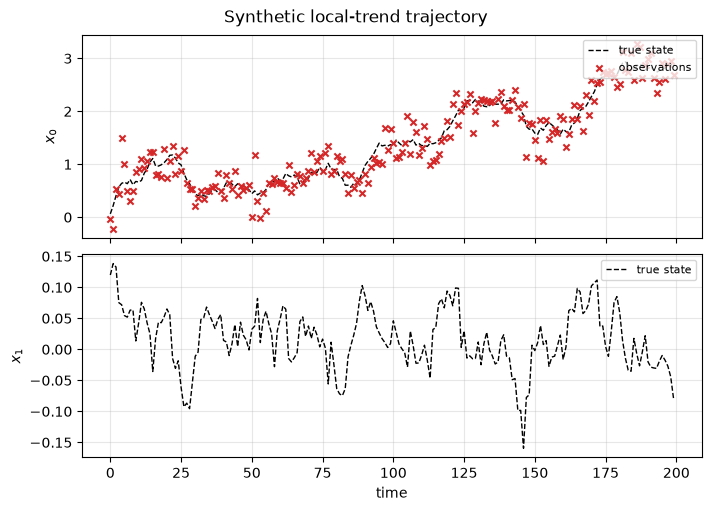

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, constrained_layout=True)
axes[0].plot(plot_times, true_states[:, 0], "k--", lw=1, label="true state")
axes[0].scatter(
    obs_times,
    obs_values[:, 0],
    color="C3",
    marker="x",
    s=20,
    label="observations",
    zorder=3,
)
axes[0].set_ylabel("$x_0$")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(plot_times, true_states[:, 1], "k--", lw=1, label="true state")
axes[1].set_ylabel("$x_1$")
axes[1].set_xlabel("time")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True, alpha=0.3)
fig.suptitle("Synthetic local-trend trajectory")
plt.show()

## Smoothing at fixed parameters

First, keep `alpha` fixed at the true value and ask only for smoothed state summaries. Because this model is linear and Gaussian, `KFSmootherConfig(filter_source="cd_dynamax")` gives an exact Kalman/Rauch-Tung-Striebel smoother.

The `record_smoothed_*` options add deterministic sites to the NumPyro trace. This is the smoothing analogue of recording filtered means and covariances in the filtering tutorial.

In [5]:
smooth_predictive = Predictive(
    local_trend_model,
    params={"alpha": alpha_true},
    num_samples=1,
    exclude_deterministic=False,
)

with Smoother(
    smoother_config=KFSmootherConfig(
        filter_source="cd_dynamax",
        record_smoothed_states_mean=True,
        record_smoothed_states_cov_diag=True,
    )
):
    smoothed = smooth_predictive(
        jr.PRNGKey(1),
        obs_times=obs_times,
        obs_values=obs_values,
    )

smoothed_mean = smoothed["f_smoothed_states_mean"][0]
smoothed_var = smoothed["f_smoothed_states_cov_diag"][0]
smoothed_sd = jnp.sqrt(jnp.maximum(smoothed_var, 1e-9))

smoothed_mean.shape, smoothed_var.shape

((200, 2), (200, 2))

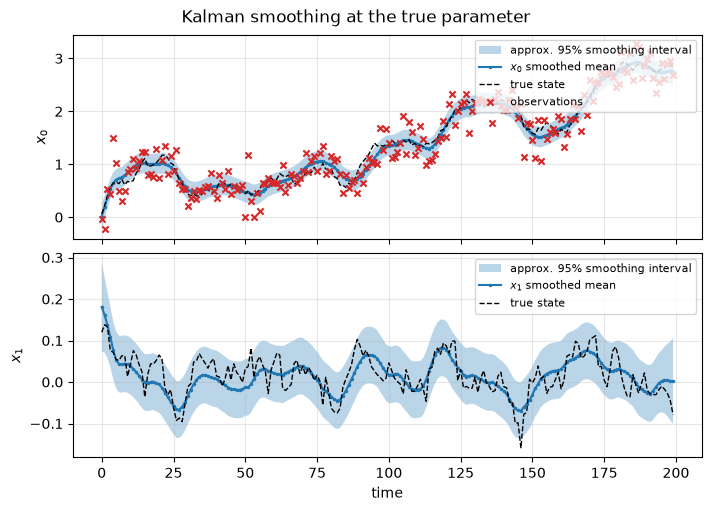

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, constrained_layout=True)

for i, ax in enumerate(axes):
    ax.fill_between(
        obs_times,
        smoothed_mean[:, i] - 2.0 * smoothed_sd[:, i],
        smoothed_mean[:, i] + 2.0 * smoothed_sd[:, i],
        alpha=0.3,
        label="approx. 95% smoothing interval",
    )
    ax.plot(obs_times, smoothed_mean[:, i], "C0.-", markersize=3, label=f"$x_{i}$ smoothed mean")
    ax.plot(obs_times, true_states[:, i], "k--", lw=1, label="true state")
    if i == 0:
        ax.scatter(
            obs_times,
            obs_values[:, 0],
            color="C3",
            marker="x",
            s=20,
            label="observations",
            zorder=3,
        )
    ax.set_ylabel(f"$x_{i}$")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("time")
fig.suptitle("Kalman smoothing at the true parameter")
plt.show()

The velocity is never observed directly, but it is still reconstructed. This is the main practical difference from a raw simulator trace: smoothing uses all observations to infer a latent path, not just to generate one.

## Filtering versus smoothing distributions

Now compare that smoother to the corresponding Kalman filter. The filter computes

$$
p(x_k \mid y_0, \ldots, y_k),
$$

while the smoother computes

$$
p(x_k \mid y_0, \ldots, y_T).
$$

Both calculations use the same model, the same observations, and the same fixed value of `alpha`. The only difference is whether the state estimate at time $k$ is allowed to use future observations.

In [7]:
filter_predictive = Predictive(
    local_trend_model,
    params={"alpha": alpha_true},
    num_samples=1,
    exclude_deterministic=False,
)

with Filter(
    filter_config=KFConfig(
        filter_source="cd_dynamax",
        record_filtered_states_mean=True,
        record_filtered_states_cov_diag=True,
    )
):
    filtered = filter_predictive(
        jr.PRNGKey(11),
        obs_times=obs_times,
        obs_values=obs_values,
    )

filtered_mean = filtered["f_filtered_states_mean"][0]
filtered_var = filtered["f_filtered_states_cov_diag"][0]
filtered_sd = jnp.sqrt(jnp.maximum(filtered_var, 1e-9))

terminal_mean_gap = jnp.max(jnp.abs(filtered_mean[-1] - smoothed_mean[-1]))
terminal_sd_gap = jnp.max(jnp.abs(filtered_sd[-1] - smoothed_sd[-1]))

filtered_mean.shape, terminal_mean_gap, terminal_sd_gap

((200, 2), Array(0., dtype=float32), Array(0., dtype=float32))

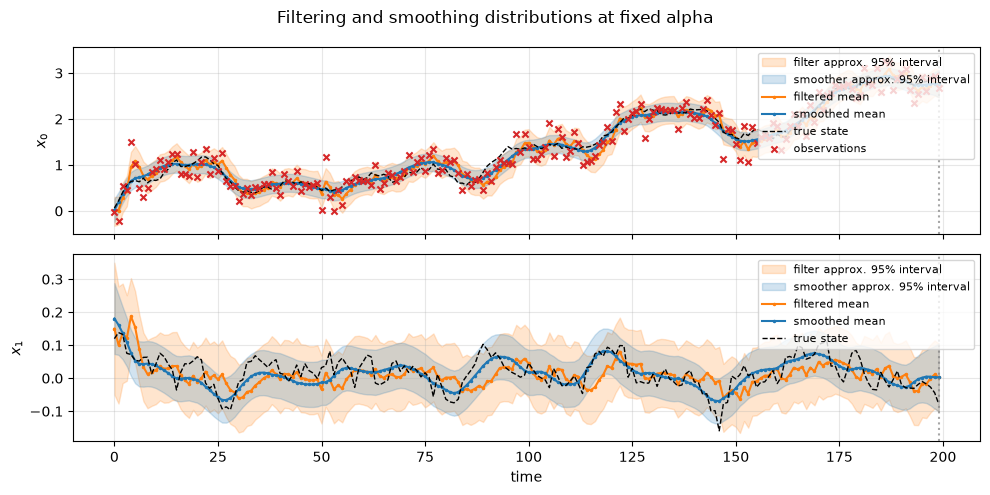

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

for i, ax in enumerate(axes):
    ax.fill_between(
        obs_times,
        filtered_mean[:, i] - 2.0 * filtered_sd[:, i],
        filtered_mean[:, i] + 2.0 * filtered_sd[:, i],
        color="C1",
        alpha=0.2,
        label="filter approx. 95% interval",
    )
    ax.fill_between(
        obs_times,
        smoothed_mean[:, i] - 2.0 * smoothed_sd[:, i],
        smoothed_mean[:, i] + 2.0 * smoothed_sd[:, i],
        color="C0",
        alpha=0.2,
        label="smoother approx. 95% interval",
    )
    ax.plot(obs_times, filtered_mean[:, i], "C1.-", markersize=3, label="filtered mean")
    ax.plot(obs_times, smoothed_mean[:, i], "C0.-", markersize=3, label="smoothed mean")
    ax.plot(obs_times, true_states[:, i], "k--", lw=1, label="true state")
    if i == 0:
        ax.scatter(
            obs_times,
            obs_values[:, 0],
            color="C3",
            marker="x",
            s=20,
            label="observations",
            zorder=3,
        )
    ax.axvline(float(obs_times[-1]), color="gray", linestyle=":", alpha=0.7)
    ax.set_ylabel(f"$x_{i}$")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("time")
fig.suptitle("Filtering and smoothing distributions at fixed alpha")
plt.tight_layout()
plt.show()

The two distributions agree at the final observation time, because there are no future observations left for the smoother to use there. Earlier in the window, the smoother can shift the mean and usually tightens the marginal uncertainty because it conditions on observations from both sides of each state.

## Parameter inference with the smoother marginal likelihood

`Smoother` also adds the marginal log-likelihood as a NumPyro factor. That means we can use NUTS to infer `alpha` without sampling the full latent trajectory as part of the Markov chain.

This is the same compositional pattern as the filtering tutorial: data-condition the model inside a handler, then hand the resulting NumPyro program to an inference algorithm.

In [9]:
def smoothed_parameter_model():
    with Smoother(
        smoother_config=KFSmootherConfig(
            filter_source="cd_dynamax",
            record_smoothed_states_mean=True,
        )
    ):
        return local_trend_model(obs_times=obs_times, obs_values=obs_values)


nuts = NUTS(smoothed_parameter_model)
mcmc = MCMC(nuts, num_warmup=100, num_samples=100)
mcmc.run(jr.PRNGKey(2))
posterior = mcmc.get_samples()

  0%|          | 0/200 [00:00<?, ?it/s]

warmup:   5%|▌         | 10/200 [00:01<00:25,  7.52it/s, 1 steps of size 3.77e-01. acc. prob=0.70]

warmup:  20%|██        | 41/200 [00:01<00:04, 36.83it/s, 3 steps of size 4.99e-01. acc. prob=0.77]

warmup:  29%|██▉       | 58/200 [00:01<00:02, 52.82it/s, 1 steps of size 1.23e+00. acc. prob=0.78]

warmup:  43%|████▎     | 86/200 [00:01<00:01, 86.13it/s, 1 steps of size 2.98e-01. acc. prob=0.78]

sample:  56%|█████▌    | 112/200 [00:01<00:00, 115.98it/s, 7 steps of size 8.94e-01. acc. prob=0.92]

sample:  68%|██████▊   | 137/200 [00:01<00:00, 141.94it/s, 3 steps of size 8.94e-01. acc. prob=0.94]

sample:  84%|████████▎ | 167/200 [00:01<00:00, 176.41it/s, 7 steps of size 8.94e-01. acc. prob=0.94]

sample:  98%|█████████▊| 197/200 [00:02<00:00, 205.51it/s, 3 steps of size 8.94e-01. acc. prob=0.94]

sample: 100%|██████████| 200/200 [00:02<00:00, 97.42it/s, 7 steps of size 8.94e-01. acc. prob=0.94] 

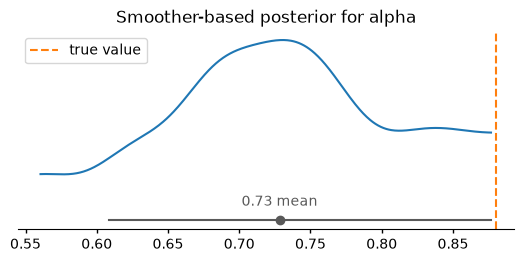

Array(0.72827786, dtype=float32)

In [10]:
dt = az.from_dict({"posterior": {"alpha": np.asarray(posterior["alpha"])[None, :]}})
pc = az.plot_dist(dt, kind="kde", ci_kind="hdi", ci_prob=0.95, point_estimate="mean")
ax = pc.viz["plot"]["alpha"].item()
ax.axvline(float(alpha_true), color="C1", ls="--", lw=1.5, label="true value")
ax.legend()
ax.set_title("Smoother-based posterior for alpha")
plt.show()

alpha_post_mean = jnp.mean(posterior["alpha"])
alpha_post_mean

## Future prediction from the final smoothed state

After fitting, a common workflow is to forecast from the end of the data window. Under `Smoother`, this forecast starts from the final smoothed state distribution, not from the prior and not from a filtered-only state.

Below we recompute the smoothing summary and the rollout using the same posterior-mean value of `alpha`. This matters: the earlier smoothed curve was computed at the true value of `alpha`, while the forecast uses an estimated value. Mixing those two summaries can create an artificial visual jump at the boundary.

For this release, this is the only prediction mode supported by `Smoother`: every requested prediction time must be at or after the final observation time. Recall, however, that arbitrary (i.e., in-window) `predict_times` are supported by the `Filter(...)` interface.

In [11]:
future_times = jnp.arange(obs_times[-1], obs_times[-1] + 40.0, 1.0)

forecast_predictive = Predictive(
    local_trend_model,
    params={"alpha": alpha_post_mean},
    num_samples=1,
    exclude_deterministic=False,
)

n_rollout = 1_000

with DiscreteTimeSimulator(n_simulations=n_rollout):
    with Smoother(
        smoother_config=KFSmootherConfig(
            filter_source="cd_dynamax",
            record_smoothed_states_mean=True,
            record_smoothed_states_cov_diag=True,
        )
    ):
        forecast = forecast_predictive(
            jr.PRNGKey(3),
            obs_times=obs_times,
            obs_values=obs_values,
            predict_times=future_times,
        )

forecast_smoothed_mean = forecast["f_smoothed_states_mean"][0]
forecast_smoothed_var = forecast["f_smoothed_states_cov_diag"][0]
forecast_smoothed_sd = jnp.sqrt(jnp.maximum(forecast_smoothed_var, 1e-9))

forecast_states = forecast["f_predicted_states"][0]
forecast_mean = forecast_states.mean(axis=0)
forecast_lo = jnp.percentile(forecast_states, 5.0, axis=0)
forecast_hi = jnp.percentile(forecast_states, 95.0, axis=0)

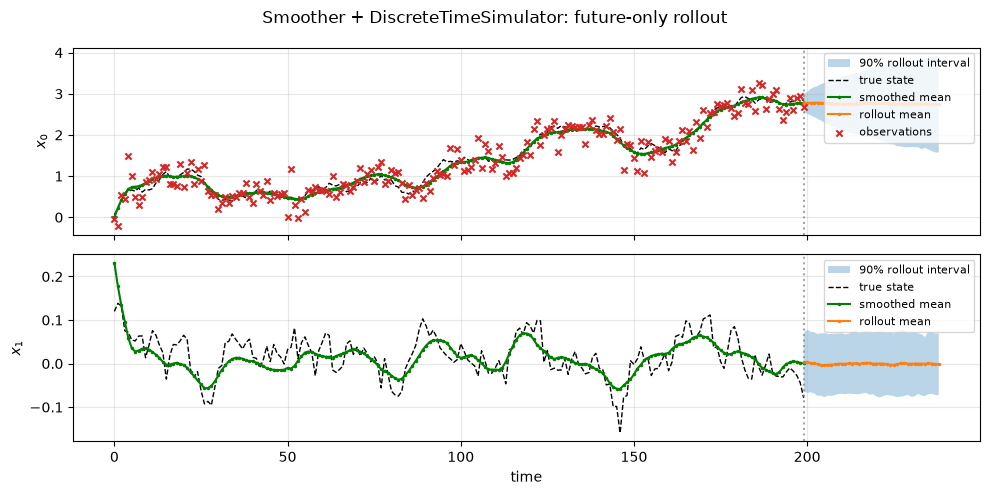

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

for i, ax in enumerate(axes):
    ax.fill_between(
        future_times,
        forecast_lo[:, i],
        forecast_hi[:, i],
        alpha=0.3,
        label="90% rollout interval",
    )
    ax.plot(obs_times, true_states[:, i], "k--", lw=1, label="true state")
    ax.plot(obs_times, forecast_smoothed_mean[:, i], "g.-", markersize=3, label="smoothed mean")
    ax.plot(future_times, forecast_mean[:, i], "C1.-", markersize=3, label="rollout mean")
    ax.axvline(float(obs_times[-1]), color="gray", linestyle=":", alpha=0.7)
    if i == 0:
        ax.scatter(
            obs_times,
            obs_values[:, 0],
            color="C3",
            marker="x",
            s=20,
            label="observations",
            zorder=3,
        )
    ax.set_ylabel(f"$x_{i}$")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("time")
fig.suptitle("Smoother + DiscreteTimeSimulator: future-only rollout")
plt.tight_layout()
plt.show()

## Takeaways

- `Filter` records causal distributions $p(x_t \mid y_{1:t})$; `Smoother` records retrospective distributions $p(x_t \mid y_{1:T})$.
- `Smoother` computes the marginal likelihood and smoothing distributions $p(x_t \mid y_{1:T})$.
- For linear-Gaussian discrete-time systems, `KFSmootherConfig` gives exact RTS smoothing.
- Smoothed summaries are recorded through `record_smoothed_*` options.
- Future prediction under `Smoother` starts from the final smoothed state distribution.
- In-window prediction is intentionally rejected until its semantics are implemented safely.